<a href="https://colab.research.google.com/github/hitomitsu50/Sports_data_portfolio_MLB_Statcast/blob/main/2025%E5%B9%B4Statcast%E5%A4%A7%E8%B0%B7%E6%8A%95%E6%89%8B%E3%81%AE%E6%8A%95%E7%90%83%E5%89%B2%E5%90%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#ライブラリーのインストール
!pip install pybaseball japanize_matplotlib
!sudo apt-get -y update
!sudo apt-get -y install fonts-ipaexfont

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 71.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.7/432.7 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.6 MB/s eta 0:00:00
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=ccca2007d241486250504ba606a3d5b01c4716a8aa25e4d5ef50b6c82bb1e55e
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize_matplotlib
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubu

In [2]:
#ライブラリーのインポート
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import japanize_matplotlib
import time
import glob
from pybaseball import statcast

In [3]:
#データの読み込みと結合
#ファイル名パターンに一致するＣＳＶを取得
csv_files_pattern="sample_data/statcast_*.csv"
csv_files=glob.glob(csv_files_pattern)

In [4]:
#各ＣＳＶファイルを読み込みリストに格納
dfs=[]
for file in csv_files:
  try:
    df_month=pd.read_csv(file)
    dfs.append(df_month)
    print(f"{file}を読み込みました。")
  except Exception as e:
    print(f"{file}の読み込み中にエラーが発生しました。:{e}")

sample_data/statcast_2025-09-01-2025-09-28.csvを読み込みました。
sample_data/statcast_2025-03-18-2025-03-31.csvを読み込みました。
sample_data/statcast_2025-06-01-2025-06-30.csvを読み込みました。
sample_data/statcast_2025-07-01-2025-07-31.csvを読み込みました。
sample_data/statcast_2025-08-01-2025-08-31.csvを読み込みました。
sample_data/statcast_2025-05-01-2025-05-31.csvを読み込みました。
sample_data/statcast_2025-04-01-2025-04-30.csvを読み込みました。


In [5]:
#全てのデータを結合
if dfs:
  df_combined=pd.concat(dfs,ignore_index=True)
  df=df_combined
  print("全てのデータフレームを結合しました。")
  display(df.head())
  print(f"結合後の行数{len(df)}")
else:
  print("読み込めるファイルが見つかりませんでした。")

全てのデータフレームを結合しました。


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,FF,2025-09-28,95.7,-2.15,5.21,"Weissert, Greg",678009,669711,field_out,hit_into_play,...,2.0,1.56,0.71,-0.71,20.9,5.991833,-1.319512,28.782516,41.559201,30.599805
1,FF,2025-09-28,95.1,-1.91,5.10,"Weissert, Greg",668670,669711,strikeout,called_strike,...,9.0,1.59,0.93,0.93,20.5,NaN,NaN,NaN,NaN,NaN
2,FF,2025-09-28,95.4,-1.99,5.22,"Weissert, Greg",668670,669711,NaN,foul,...,9.0,1.36,0.85,0.85,22.9,2.871131,31.805044,22.266527,37.478847,15.582717
3,SL,2025-09-28,84.8,-2.33,4.72,"Weissert, Greg",668670,669711,NaN,swinging_strike,...,9.0,2.55,-0.32,-0.32,12.3,13.785410,4.081390,32.414181,38.011685,27.083341
4,SL,2025-09-28,85.3,-2.26,4.85,"Weissert, Greg",668670,669711,NaN,called_strike,...,9.0,2.71,-0.52,-0.52,15.8,NaN,NaN,NaN,NaN,NaN


結合後の行数742080


In [6]:
#読み込まれた各ＣＳＶの行数を確認する
for file in csv_files:
  temp_df=pd.read_csv(file)
  print(f"{file}: {len(temp_df)}行")

sample_data/statcast_2025-09-01-2025-09-28.csv: 110338行
sample_data/statcast_2025-03-18-2025-03-31.csv: 49338行
sample_data/statcast_2025-06-01-2025-06-30.csv: 115816行
sample_data/statcast_2025-07-01-2025-07-31.csv: 107305行
sample_data/statcast_2025-08-01-2025-08-31.csv: 124298行
sample_data/statcast_2025-05-01-2025-05-31.csv: 120218行
sample_data/statcast_2025-04-01-2025-04-30.csv: 114767行


In [7]:
# --- 1. データの抽出と基本集計 ---
target_name_display="Shohei Ohtani"
df_target=df[df["player_name"].str.contains("Ohtani, Shohei")].copy()

#球種ごとのカウント、平均球速、平均回転数
pitch_stats=df_target.groupby("pitch_type").agg({
    "pitch_type":"count",
    "release_speed":"mean",
    "release_spin_rate":"mean"
}).rename(columns={"pitch_type":"count"}).sort_values("count",ascending=False)

In [9]:
# --- 2. Whiff% とPutAway%の計算 ---
#Whiff%=空振り/スイング
swings=df_target[df_target["description"].isin(["swinging_strike","foul","foul_tip","hit_into_play","swinging_strike_blocjed"])]
whiffs=df_target[df_target["description"].isin(["swinging_strike","swinging_strike_blocked"])]

#PutAway%=2ストライクからの三振/2ストライクの投球数
two_strikes=df_target[df_target["strikes"]==2]
strikeouts=two_strikes[df_target["events"].isin(["strikeout","strikeout_double_play"])]

#球種ごとの計算値を結合
pitch_stats["whiff_pct"]=(whiffs.groupby("pitch_type").size()/swings.groupby("pitch_type").size()*100)
pitch_stats["putaway_pct"]=(strikeouts.groupby("pitch_type").size()/two_strikes.groupby("pitch_type").size()*100)
pitch_stats["usage_pct"]=(pitch_stats["count"]/pitch_stats["count"].sum()*100)

/tmp/ipykernel_247/3710905658.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  strikeouts=two_strikes[df_target["events"].isin(["strikeout","strikeout_double_play"])]


/tmp/ipykernel_247/509063801.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pitch_stats.index,y=pitch_stats["usage_pct"],ax=ax1,palette="Blues_d",alpha=0.7)


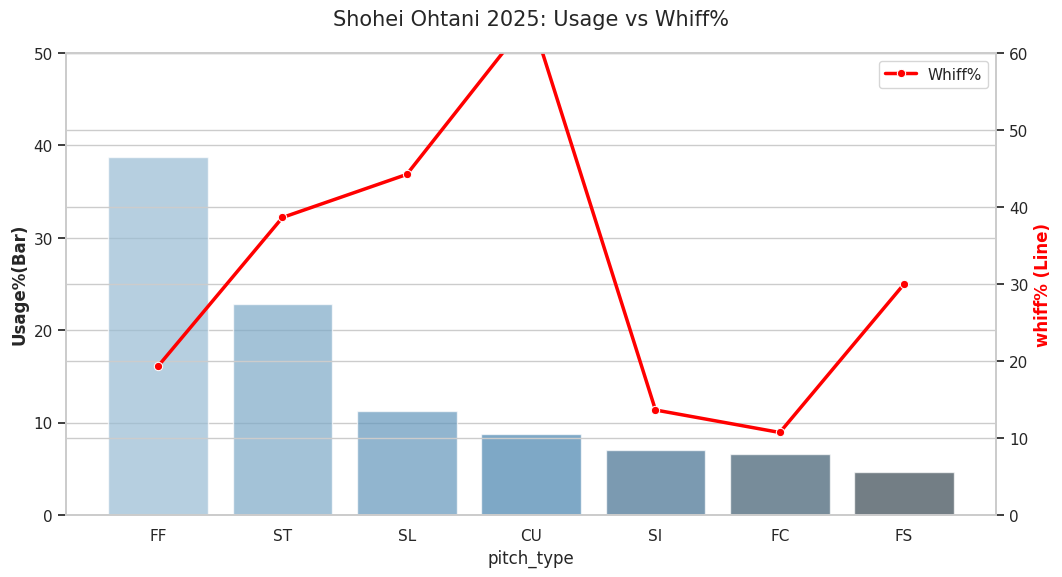

In [12]:
# --- 3. 可視化(２軸棒グラフ : 割合 × Whiffs%) ---
fig,ax1=plt.subplots(figsize=(12,6))
sns.set_theme(style="whitegrid")

#左軸:投球割合（棒グラフ）
sns.barplot(x=pitch_stats.index,y=pitch_stats["usage_pct"],ax=ax1,palette="Blues_d",alpha=0.7)
ax1.set_ylabel("Usage%(Bar)",fontsize=12,fontweight="bold")
ax1.set_ylim(0, 50)

#右軸:Whiff%(折れ線グラフ)
ax2=ax1.twinx()
sns.lineplot(x=pitch_stats.index,y=pitch_stats["whiff_pct"],ax=ax2,color="red",marker="o",linewidth="2.5",label="Whiff%")
ax2.set_ylabel("whiff% (Line)",color="red",fontsize=12,fontweight="bold")
ax2.set_ylim(0, 60)

plt.title(f"{target_name_display} 2025: Usage vs Whiff%",fontsize=15,pad=20)
plt.show()

In [14]:
# --- 4. テキストの出力(df) ---
jp_names={"FF":"フォーシーム","FS":"スプリット","CU":"カーブ","FC":"カットボール","SI":"シンカー","SL":"スライダー","ST":"スイーパー","CH":"チェンジアップ"}

table_data=[]
for pitch in pitch_stats.index:
  row=pitch_stats.loc[pitch]
  table_data.append({
      "略称":pitch,
      "日本語名":jp_names.get(pitch, pitch),
      "投球数":int(row["count"]),
      "割合":f"{row["usage_pct"]:.1f}%",
      "平均球速":f"{row["release_speed"]:.1f} mph",
      "回転数":f"{int(row["release_spin_rate"])} rpm",
      "Whiff%":f"{row["whiff_pct"]:.1f}%",
      "PutAway%":f"{row["putaway_pct"]:.1f}%"
  })
print(f"###{target_name_display} 2025 Pitch Mix Detail")
display(pd.DataFrame(table_data))
print(f"Total Pitches: {int(pitch_stats["count"].sum())}")

###Shohei Ohtani 2025 Pitch Mix Detail


,略称,日本語名,投球数,割合,平均球速,回転数,Whiff%,PutAway%
0,FF,フォーシーム,292,38.8%,98.4 mph,2467 rpm,19.3%,22.0%
1,ST,スイーパー,172,22.8%,85.0 mph,2593 rpm,38.6%,35.3%
2,SL,スライダー,85,11.3%,88.1 mph,2546 rpm,44.2%,32.6%
3,CU,カーブ,66,8.8%,78.6 mph,2653 rpm,64.7%,34.6%
4,SI,シンカー,53,7.0%,96.2 mph,2137 rpm,13.6%,nan%
5,FC,カットボール,50,6.6%,93.9 mph,2531 rpm,10.7%,25.0%
6,FS,スプリット,35,4.6%,90.3 mph,1507 rpm,30.0%,6.2%


Total Pitches: 753
